# Speech Processing

# Lab Assignment 5

# Name: Saran Jayakumar Palani
# Reg No: BL.EN.U4AIE23131

## Objective
1. To understand how to construct a triangular filter
2. To learn how multiple triangular filters form a filter bank
3. To design and visualize a Mel Filter Bank
4. To understand the need for FFT bin mapping

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## Objective 1: Construction of Triangular Filters
A triangular filter is defined by three points: left (a), center (b), and right (c).

$$
T(k)=\begin{cases}
0, & k<a \\ 
\frac{k-a}{b-a}, & a\leq k\leq b \\ 
\frac{c-k}{c-b}, & b\leq k\leq c \\ 
0, & k>c
\end{cases}
$$

In [2]:
def triangular_filter(k, a, b, c):
    y = np.zeros_like(k, dtype=float)

    rising = (k >= a) & (k <= b)
    falling = (k >= b) & (k <= c)

    if b != a:
        y[rising] = (k[rising] - a) / (b - a)
    if c != b:
        y[falling] = (c - k[falling]) / (c - b)

    return y

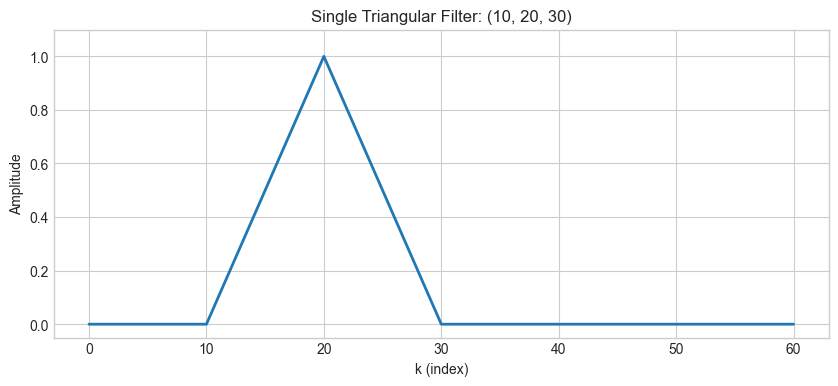

In [ ]:
k = np.arange(0, 61)
single_triangle = triangular_filter(k, 10, 20, 30)

plt.figure(figsize=(10, 4))
plt.plot(k, single_triangle, linewidth=2)
plt.title('Single Triangular Filter: (10, 20, 30)')
plt.xlabel('k (index)')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.1)
plt.show()

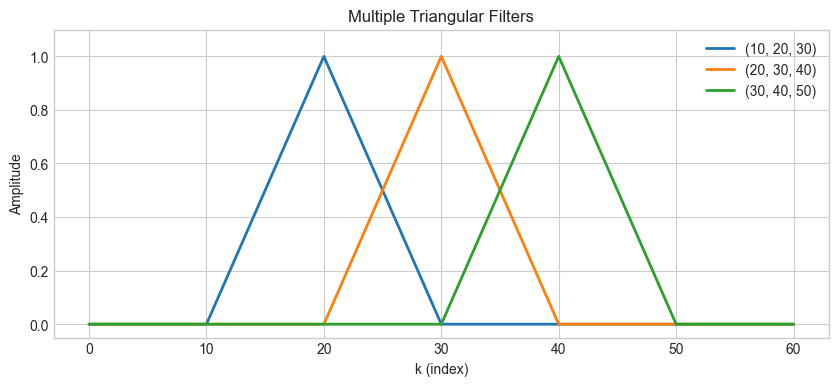

In [ ]:
triangle_points = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]

plt.figure(figsize=(10, 4))
for a, b, c in triangle_points:
    y = triangular_filter(k, a, b, c)
    plt.plot(k, y, linewidth=2, label=f'({a}, {b}, {c})')

plt.title('Multiple Triangular Filters')
plt.xlabel('k (index)')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.1)
plt.legend()
plt.show()

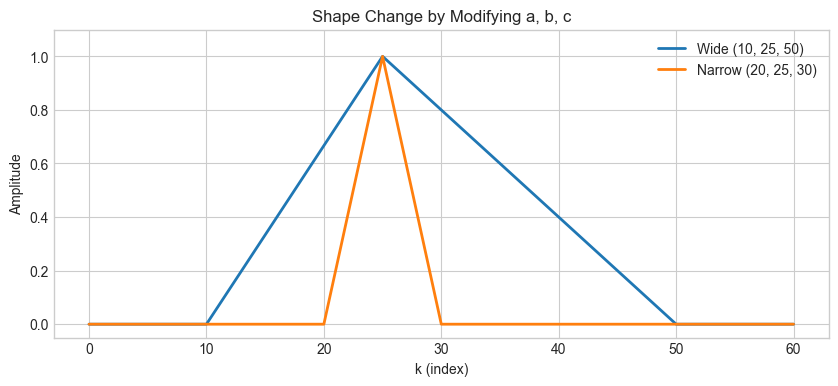

In [ ]:
wide_points = (10, 25, 50)
narrow_points = (20, 25, 30)

wide_triangle = triangular_filter(k, *wide_points)
narrow_triangle = triangular_filter(k, *narrow_points)

plt.figure(figsize=(10, 4))
plt.plot(k, wide_triangle, linewidth=2, label=f'Wide {wide_points}')
plt.plot(k, narrow_triangle, linewidth=2, label=f'Narrow {narrow_points}')
plt.title('Shape Change by Modifying a, b, c')
plt.xlabel('k (index)')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.1)
plt.legend()
plt.show()

## Objective 2: Mel Filter Bank Design
### Step 1: Define Parameters
- Sampling frequency: $f_s=16000$ Hz
- FFT size: $N=512$
- Number of filters: $M=20$

In [6]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)


def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)


def design_mel_filter_bank(fs=16000, N=512, M=20, fmin=0, fmax=None):
    if fmax is None:
        fmax = fs / 2

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, M + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((N + 1) * hz_points / fs).astype(int)
    bins = np.clip(bins, 0, N // 2)

    filter_bank = np.zeros((M, N // 2 + 1))

    for m in range(1, M + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        if center > left:
            for k in range(left, center + 1):
                filter_bank[m - 1, k] = (k - left) / (center - left)

        if right > center:
            for k in range(center, right + 1):
                filter_bank[m - 1, k] = (right - k) / (right - center)

    return filter_bank, mel_points, hz_points, bins

In [ ]:
fs = 16000
N = 512
M = 20
fmin = 0
fmax = fs / 2

mel_fb, mel_points, hz_points, bin_points = design_mel_filter_bank(fs, N, M, fmin, fmax)

print(f'fs = {fs} Hz, N = {N}, M = {M}')
print(f'Mel min = {mel_points[0]:.2f}, Mel max = {mel_points[-1]:.2f}')

fs = 16000 Hz, N = 512, M = 20
Mel min = 0.00, Mel max = 2840.02


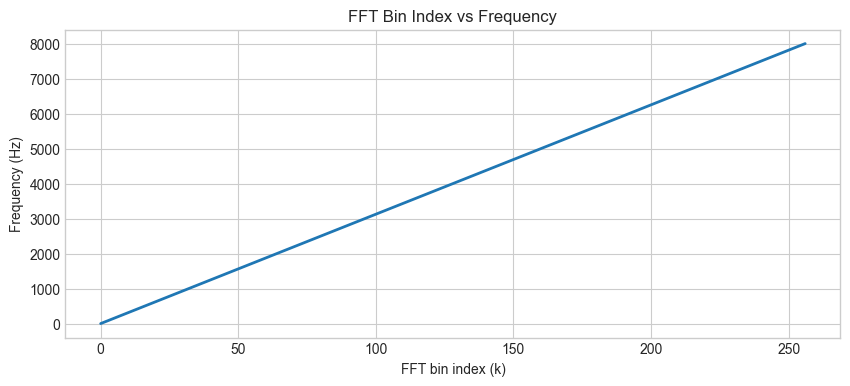

In [ ]:
k_bins = np.arange(0, N // 2 + 1)
freq_axis = k_bins * fs / N

plt.figure(figsize=(10, 4))
plt.plot(k_bins, freq_axis, linewidth=2)
plt.title('FFT Bin Index vs Frequency')
plt.xlabel('FFT bin index (k)')
plt.ylabel('Frequency (Hz)')
plt.show()

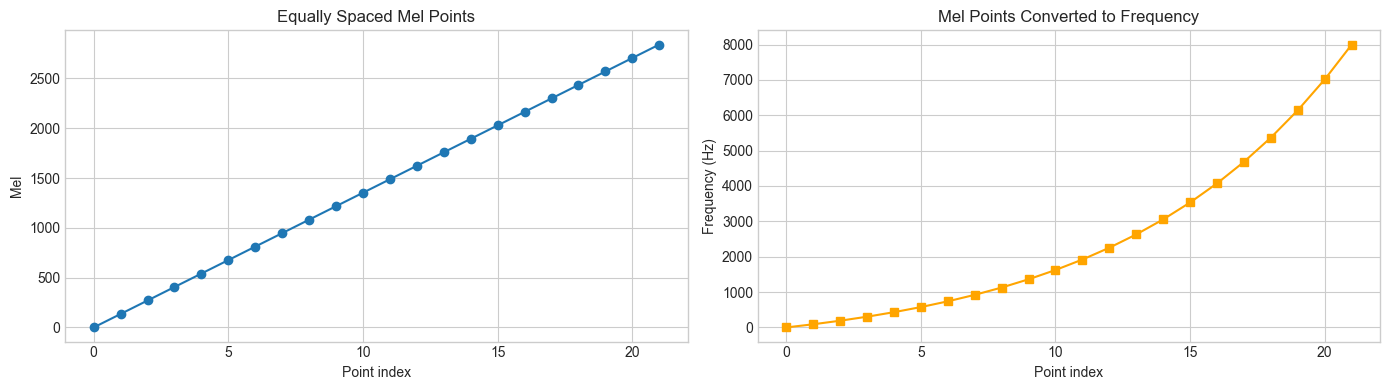

In [ ]:
idx = np.arange(len(mel_points))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(idx, mel_points, marker='o')
axes[0].set_title('Equally Spaced Mel Points')
axes[0].set_xlabel('Point index')
axes[0].set_ylabel('Mel')

axes[1].plot(idx, hz_points, marker='s', color='orange')
axes[1].set_title('Mel Points Converted to Frequency')
axes[1].set_xlabel('Point index')
axes[1].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

In [ ]:
print('Triangular filter points in FFT bins and Hz:')
for m in range(1, M + 1):
    a_bin, b_bin, c_bin = bin_points[m - 1], bin_points[m], bin_points[m + 1]
    a_hz, b_hz, c_hz = hz_points[m - 1], hz_points[m], hz_points[m + 1]
    print(
        f'Filter {m:02d}: a={a_bin:3d}, b={b_bin:3d}, c={c_bin:3d}  '
        f'|  ({a_hz:7.2f}, {b_hz:7.2f}, {c_hz:7.2f}) Hz'
    )

Triangular filter points in FFT bins and Hz:
Filter 01: a=  0, b=  2, c=  6  |  (   0.00,   89.25,  189.87) Hz
Filter 02: a=  2, b=  6, c=  9  |  (  89.25,  189.87,  303.33) Hz
Filter 03: a=  6, b=  9, c= 13  |  ( 189.87,  303.33,  431.25) Hz
Filter 04: a=  9, b= 13, c= 18  |  ( 303.33,  431.25,  575.48) Hz
Filter 05: a= 13, b= 18, c= 23  |  ( 431.25,  575.48,  738.10) Hz
Filter 06: a= 18, b= 23, c= 29  |  ( 575.48,  738.10,  921.46) Hz
Filter 07: a= 23, b= 29, c= 36  |  ( 738.10,  921.46, 1128.19) Hz
Filter 08: a= 29, b= 36, c= 43  |  ( 921.46, 1128.19, 1361.27) Hz
Filter 09: a= 36, b= 43, c= 52  |  (1128.19, 1361.27, 1624.08) Hz
Filter 10: a= 43, b= 52, c= 61  |  (1361.27, 1624.08, 1920.39) Hz
Filter 11: a= 52, b= 61, c= 72  |  (1624.08, 1920.39, 2254.48) Hz
Filter 12: a= 61, b= 72, c= 84  |  (1920.39, 2254.48, 2631.17) Hz
Filter 13: a= 72, b= 84, c= 97  |  (2254.48, 2631.17, 3055.88) Hz
Filter 14: a= 84, b= 97, c=113  |  (2631.17, 3055.88, 3534.75) Hz
Filter 15: a= 97, b=113, c=130 

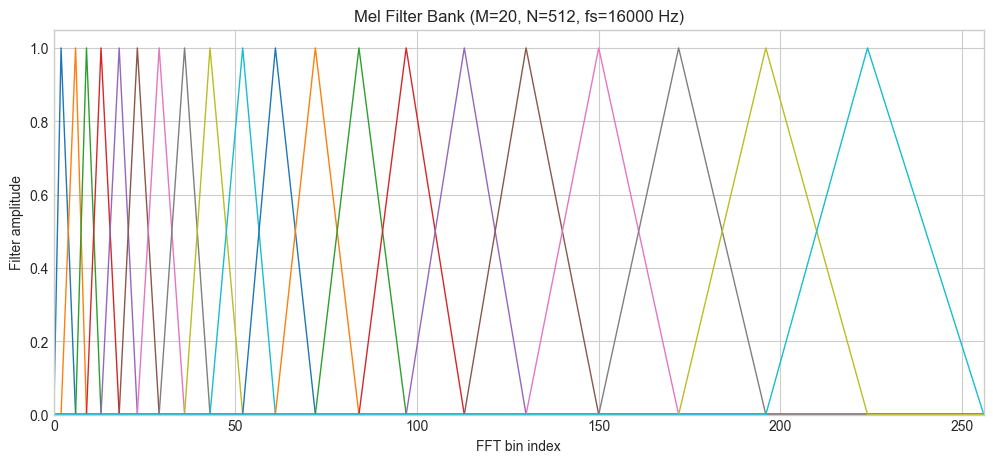

In [ ]:
plt.figure(figsize=(12, 5))
for m in range(M):
    plt.plot(mel_fb[m], linewidth=1)

plt.title(f'Mel Filter Bank (M={M}, N={N}, fs={fs} Hz)')
plt.xlabel('FFT bin index')
plt.ylabel('Filter amplitude')
plt.xlim([0, N // 2])
plt.ylim([0, 1.05])
plt.show()


Base (16000, 512, 20)
First 5 center bins: [ 2  6  9 13 18]
First 5 center frequencies (Hz): [ 89.25 189.87 303.33 431.25 575.48]

Higher N and M (16000, 1024, 26)
First 5 center bins: [ 4  9 14 20 26]
First 5 center frequencies (Hz): [ 68.48 143.66 226.19 316.8  416.27]

Lower fs (8000, 512, 20)
First 5 center bins: [ 4  8 14 19 25]
First 5 center frequencies (Hz): [ 66.44 139.19 218.84 306.06 401.55]


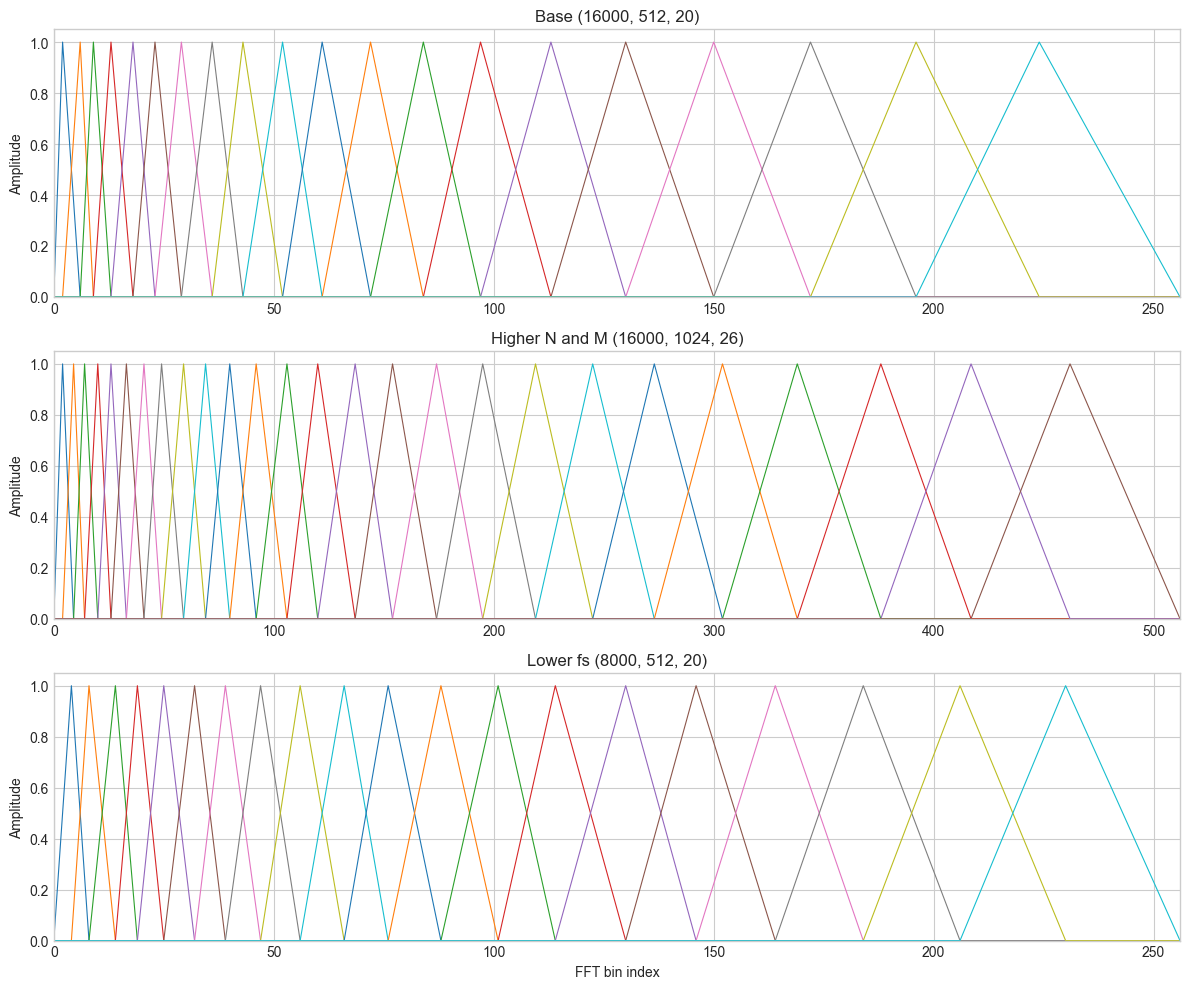

In [ ]:
configs = [
    {'fs': 16000, 'N': 512, 'M': 20, 'label': 'Base (16000, 512, 20)'},
    {'fs': 16000, 'N': 1024, 'M': 26, 'label': 'Higher N and M (16000, 1024, 26)'},
    {'fs': 8000, 'N': 512, 'M': 20, 'label': 'Lower fs (8000, 512, 20)'}
]

fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=False)

for i, cfg in enumerate(configs):
    fb, _, hz_pts, bins = design_mel_filter_bank(cfg['fs'], cfg['N'], cfg['M'])
    for m in range(cfg['M']):
        axes[i].plot(fb[m], linewidth=0.8)
    axes[i].set_title(cfg['label'])
    axes[i].set_ylabel('Amplitude')
    axes[i].set_xlim([0, cfg['N'] // 2])
    axes[i].set_ylim([0, 1.05])

    print(f"\n{cfg['label']}")
    print(f"First 5 center bins: {bins[1:6]}")
    print(f"First 5 center frequencies (Hz): {np.round(hz_pts[1:6], 2)}")

axes[-1].set_xlabel('FFT bin index')
plt.tight_layout()
plt.show()

## Why Frequency-to-Bin Mapping is Needed
FFT output is indexed by bin number $k$ rather than directly by frequency.

$$
f_k = \frac{k f_s}{N}
$$

To implement filter banks on FFT magnitudes, every filter edge/center frequency must be converted to FFT bin indices.

The center point is equally spaced in Mel scale, but it is not equally spaced in Hz or FFT bins.

## Observation
- Wider triangles cover broader frequency regions and produce smoother overlap.
- Narrow triangles improve local frequency selectivity.
- Mel filters are dense in lower frequencies and sparse in higher frequencies, matching speech perception.
- Changing $N$, $M$, and $f_s$ changes filter resolution, spacing, and coverage.